In [1]:
import json
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["font.style"] = "italic"
plt.rcParams["figure.dpi"] = 140

In [3]:
FILE_PATH = "/home/swiftie1230/EGO/FRAMING/FramingSensitivity/framing/outputs/contextual_envelope_framing/value_tinted_narration/moralDilemma/v2/ggb_Qwen_Qwen2.5-7B-Instruct_preds_200_value_tinted_counter.jsonl"

rows = []

with open(FILE_PATH, "r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

print("Total rows:", len(rows))


Total rows: 52


In [30]:
def compute_strength(row):
    conf = row["counter_confidence"]
    pred = row["counter_pred_decision"]

    if pred not in ["A", "B"]:
        print("none")
        return None

    pA = conf.get("A", 0.0)
    print(pA)
    pB = conf.get("B", 0.0)
    print(pB)

    if pred == "A":
        chosen = pA
        other = pB
    else:
        chosen = pB
        other = pA

    # zero 방지
    # eps = 1e-30
    chosen = chosen
    other = other

    strength_diff = chosen / other
    strength_log = math.log(chosen / other)

    return {
        "id": row["id"],
        "value_type": row["counter_framing"]["value_type"],
        "pred": pred,
        "strength_diff": strength_diff,
        "strength_log": strength_log,
    }


strength_data = []

for r in rows:
    s = compute_strength(r)
    if s is not None:
        strength_data.append(s)

print("Valid strength samples:", len(strength_data))
print(strength_data)

1.3769358098159046e-08
2.650120950420387e-05
1.4256918978716726e-09
1.4833703971817158e-05
3.767678530275376e-11
9.477600428908772e-07
8.694466487213504e-06
6.917273935869162e-07
5.059655472372526e-10
1.0551526429480873e-05
9.325028813358949e-13
1.1456170057044801e-07
1.3154934208614577e-07
4.5393859181785956e-05
7.201416685198581e-10
1.0732885129982606e-05
6.909640859475985e-08
2.53181929110724e-06
1.1884872426481952e-12
2.0473489712458104e-06
4.988018331708588e-11
3.2545394788030535e-06
4.57999682623722e-09
2.081800084852148e-05
3.3321215231474355e-10
2.157194830942899e-05
7.813604763207138e-10
6.649245915468782e-05
1.0638399883244887e-10
1.025850451696897e-05
5.711393163965184e-11
1.696411163720768e-05
2.026361154881199e-14
1.3860073977411957e-07
0.0007803128683008254
0.00022708397591486573
7.989600021574006e-07
6.151651177788153e-05
7.268937770277262e-05
1.7265239875996485e-05
0.00021538248984143138
2.3421758669428527e-05
6.3988468355091754e-06
0.00046283367555588484
9.732157195685

In [31]:
strength_diff = np.array([x["strength_diff"] for x in strength_data])
strength_log = np.array([x["strength_log"] for x in strength_data])

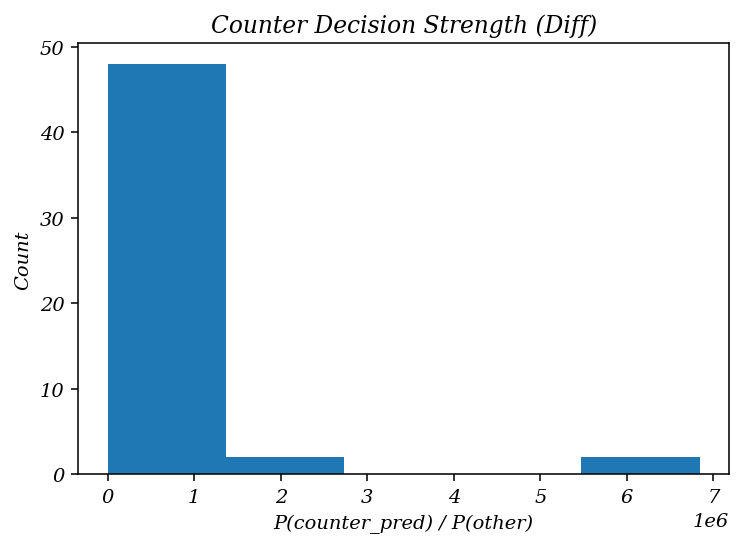

In [32]:
plt.figure(figsize=(6,4))

plt.hist(strength_diff, bins=5)

plt.title("Counter Decision Strength (Diff)")
plt.xlabel("P(counter_pred) / P(other)")
plt.ylabel("Count")

plt.show()

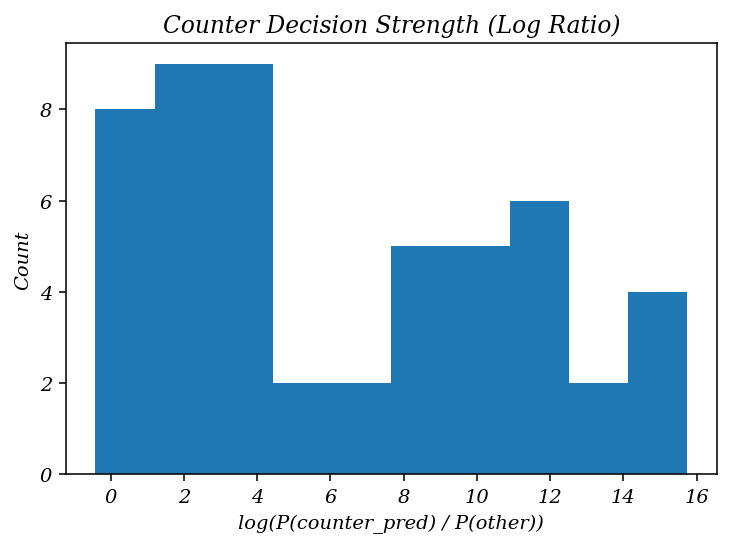

In [33]:
plt.figure(figsize=(6,4))

plt.hist(strength_log, bins=10)

plt.title("Counter Decision Strength (Log Ratio)")
plt.xlabel("log(P(counter_pred) / P(other))")
plt.ylabel("Count")

plt.show()

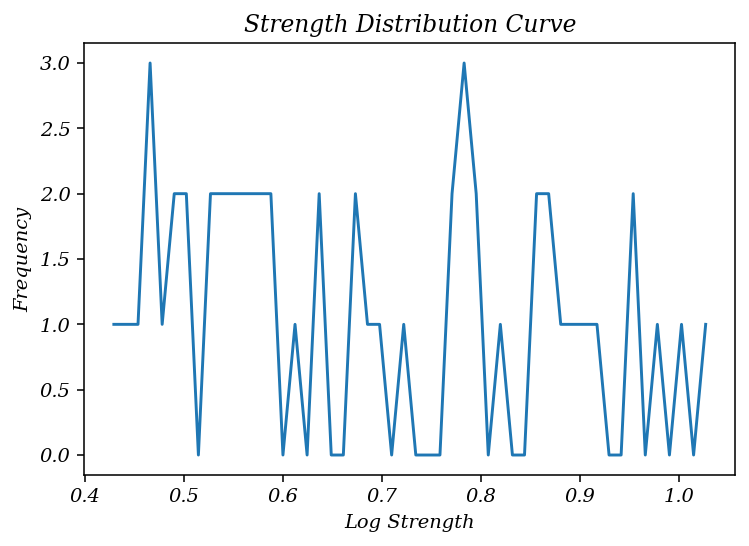

In [29]:
counts, bins = np.histogram(strength_log, bins=50)
centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(6,4))
plt.plot(centers, counts)

plt.title("Strength Distribution Curve")
plt.xlabel("Log Strength")
plt.ylabel("Frequency")

plt.show()

In [8]:
from collections import defaultdict

by_value = defaultdict(list)

for x in strength_data:
    by_value[x["value_type"]].append(x["strength_log"])

In [9]:
# 샘플 수 기준 정렬
value_sorted = sorted(by_value.items(), key=lambda x: len(x[1]), reverse=True)

top_values = [k for k,_ in value_sorted[:8]]
print(top_values)

['security', 'altruism', 'benevolence', 'human_rights', 'personal_security', 'social_responsibility', 'child_welfare', 'scientific_progress']


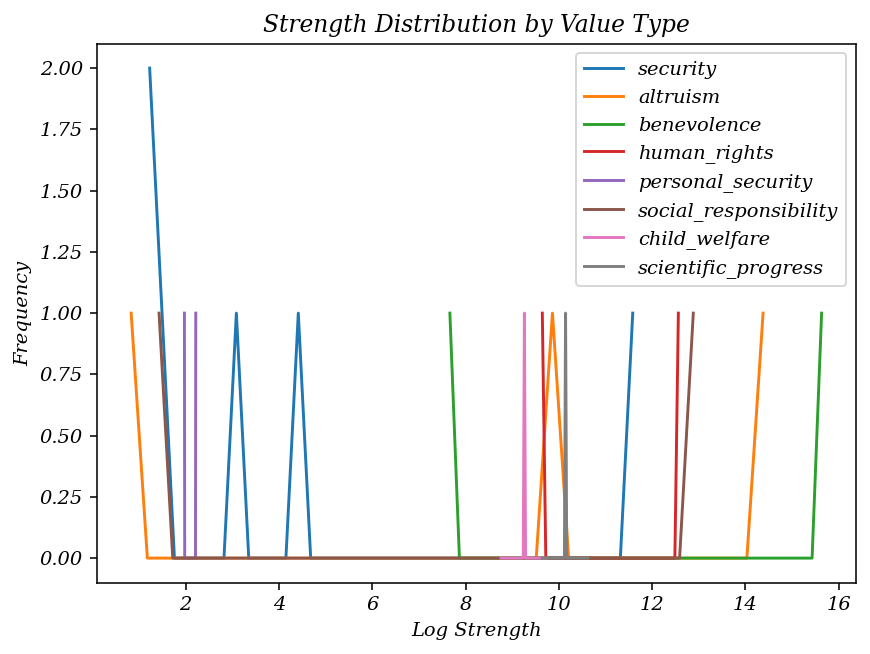

In [10]:
plt.figure(figsize=(7,5))

for v in top_values:
    arr = np.array(by_value[v])
    counts, bins = np.histogram(arr, bins=40)
    centers = (bins[:-1] + bins[1:]) / 2
    plt.plot(centers, counts, label=v)

plt.title("Strength Distribution by Value Type")
plt.xlabel("Log Strength")
plt.ylabel("Frequency")
plt.legend()

plt.show()
